In [6]:
import zarr
import os 
os.chdir("/Users/iriskwon/Desktop/mouse-cereb-dev/mouse-cereb-dev/")
os.getcwd()

'/Users/iriskwon/Desktop/mouse-cereb-dev/mouse-cereb-dev'

In [7]:
z = zarr.open("public/data/e11_data_scaled.zarr", mode="r")
print(z.tree())

/
 ├── X (37623, 1731) float32
 ├── layers
 ├── obs
 │   ├── broad_cell_types
 │   │   ├── categories (3,) object
 │   │   └── codes (37623,) int8
 │   ├── cell_globID (37623,) object
 │   ├── cell_number (37623,) int64
 │   ├── cell_types
 │   │   ├── categories (11,) object
 │   │   └── codes (37623,) int8
 │   ├── leiden
 │   │   ├── categories (14,) object
 │   │   └── codes (37623,) int8
 │   ├── library_id
 │   │   ├── categories (4,) object
 │   │   └── codes (37623,) int8
 │   ├── n_counts (37623,) int64
 │   ├── n_genes_by_counts (37623,) int64
 │   ├── timepoint
 │   │   ├── categories (1,) object
 │   │   └── codes (37623,) int8
 │   └── total_counts (37623,) int64
 ├── obsm
 │   ├── X_hvg (37623, 50) float32
 │   ├── X_pca (37623, 50) float32
 │   ├── X_umap (37623, 2) float32
 │   ├── spatial (37623, 2) uint16
 │   └── spatial3d (37623, 3) float64
 ├── obsp
 │   ├── connectivities
 │   │   ├── data (182434,) float32
 │   │   ├── indices (182434,) int32
 │   │   └── indptr 

In [9]:
import anndata as ad

# Path to the .zarr file
zarr_path = "public/data/e11_data_scaled.zarr"

# Read the AnnData object from the .zarr file
adata = ad.read_zarr(zarr_path)

# Inspect the AnnData object
print(adata)
print(adata.obs.head())  # View metadata for cells
print(adata.var.head())  # View metadata for genes

AnnData object with n_obs × n_vars = 37623 × 1731
    obs: 'cell_number', 'library_id', 'timepoint', 'n_genes_by_counts', 'total_counts', 'n_counts', 'leiden', 'broad_cell_types', 'cell_types'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'mean', 'std', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cell_types_colors', 'hvg', 'neighbors', 'pca', 'umap'
    obsm: 'X_hvg', 'X_pca', 'X_umap', 'spatial', 'spatial3d'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
             cell_number library_id timepoint  n_genes_by_counts  \
cell_globID                                                        
3070                3070     e11_A5       e11               1468   
3077                3077     e11_A5       e11                 64   
3083                3083     e11_A5       e11                 97   
3085                3085     e11_A5       e11                 75   
3092                3092     e11_A5       e1

In [10]:
adata.obsm_keys

<bound method AnnData.obsm_keys of AnnData object with n_obs × n_vars = 37623 × 1731
    obs: 'cell_number', 'library_id', 'timepoint', 'n_genes_by_counts', 'total_counts', 'n_counts', 'leiden', 'broad_cell_types', 'cell_types'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'mean', 'std', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cell_types_colors', 'hvg', 'neighbors', 'pca', 'umap'
    obsm: 'X_hvg', 'X_pca', 'X_umap', 'spatial', 'spatial3d'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'>

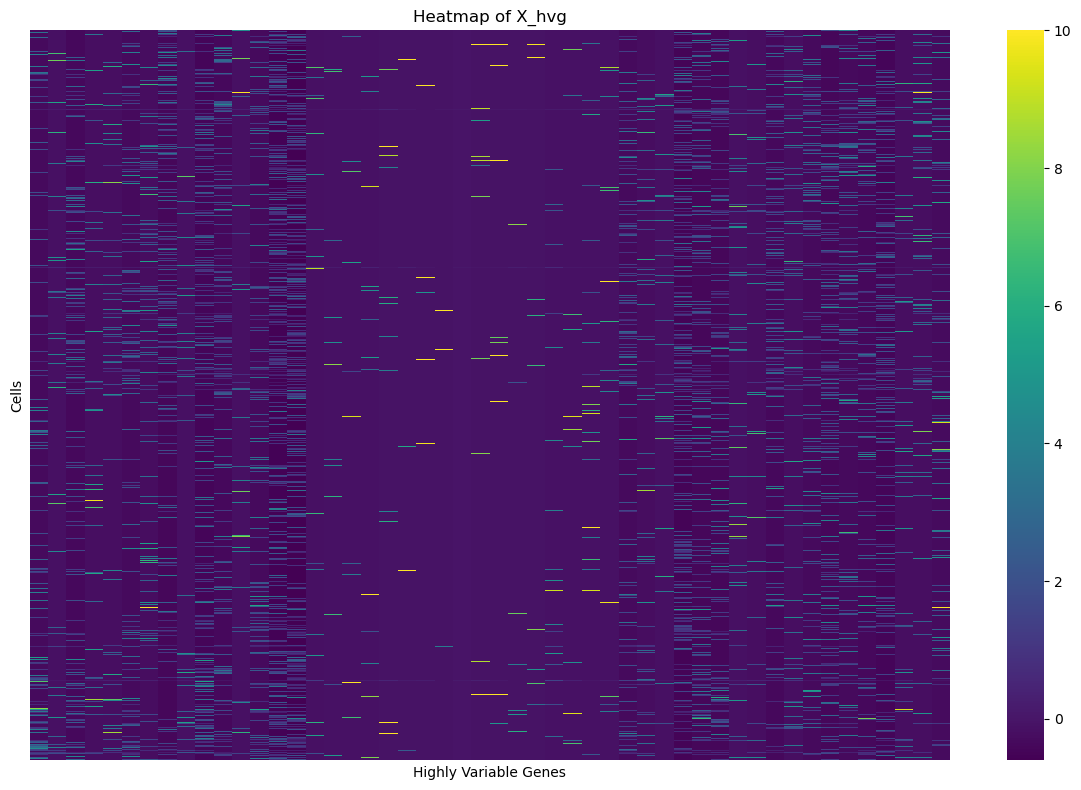

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Ensure X_hvg exists in .obsm
if "X_hvg" in adata.obsm:
    # Extract the X_hvg matrix
    X_hvg = adata.obsm["X_hvg"]

    # Create a DataFrame for better labeling (optional)
    hvg_genes = adata.var_names[:X_hvg.shape[1]]  # Adjust if gene names are stored separately
    hvg_df = pd.DataFrame(X_hvg, columns=hvg_genes, index=adata.obs_names)

    # Plot the heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(hvg_df, cmap="viridis", xticklabels=False, yticklabels=False)
    plt.title("Heatmap of X_hvg")
    plt.xlabel("Highly Variable Genes")
    plt.ylabel("Cells")
    plt.tight_layout()
    plt.show()
else:
    print("X_hvg not found in .obsm")